# 00 MuJoCo 四脚の動作確認

## 背景

学習は完成した歩行器から始めない。最初に必要なのは、シミュレータが四脚を1体置いて時間を進められることである。制御の正しさはまだ問わない。

実施は MuJoCo の Go2（[00 README](../docs/block-curriculum/00_README.md) §7）。Gazebo では走らせない。

### 成功条件（数値。ここが合否）

倒れてよい。静止は条件ではない。[README §3.8](../docs/block-curriculum/00_README.md): 一瞬ではなく **連続 5.0 秒以上**。

| 量 | 条件 | 全ステップで連続 |
|---|---|---|
| シミュレーション時間 | $t_{\mathrm{end}}\ge 5.0\,\mathrm{s}$ | 走行を 5 秒未満で切らない |
| `qpos`, `qvel` | すべて有限（`np.isfinite`） | 連続 $5.0\,\mathrm{s}$ 以上 |
| 結果 GIF | 1 本以上。実接触・合力・$mg$ | 必須 |

1 ステップだけ有限、は不合格。

## 目的

- プラントを起動し、$\tau=0$ で 5 秒以上進める
- 接地反力（実接触）と胴体への合力、重力 $mg$ を矢印にした GIF が残る
- 重力で潰れる／床に当たる様子が見える

この段に予測最適化は無い。指令 GRF も無い。矢印は MuJoCo が返した実接触である。

## 数式

全身は概念的に次である。

$$
M(q)\ddot{q} + h(q,\dot{q}) = S^{\top}\tau + J_c(q)^{\top}\lambda
$$

本 Notebook では $\tau=0$。$\lambda$ は接触ソルバーの実接触力。

## 図

```
tau = 0
    |
    v
+-----------+     lambda (4 x 3)     +----------------+
| MuJoCo    | ---------------------> | 足の矢印        |
| Go2 step  |                        | 赤: 合力        |
+-----------+                        | 灰: mg          |
    |
    +----> GIF
```

脚色: FL 青、FR 緑、RL 橙、RR 紫。

## 思考過程

制御を書く前に、プラントが `qpos` を返し、接触力を返せるかを見る。失敗なら以降の $-J^{\top}F$ は切り分けられない。

## 仮説

$\tau=0$ なら立ち姿勢キーフレームから沈む。ベース高さ $z$ は下がる。接触が出れば $F_z$ 合計が一時的に $mg$ 近くまで上がる。`qpos` は 5 秒間有限のまま。


In [1]:
# --- このセルの意図 ---
# プラントが動くことだけを確認する。制御は tau=0（重力だけ）。
# 合否は「5秒以上、qpos/qvel が有限」。倒れてもよい。

from pathlib import Path
import sys
import numpy as np
from IPython.display import Image, display  # 内容: Notebook に GIF を埋め込む

# 意図: src から plant / GIF だけ import する。脚力や tau の式は src に置かない。
here = Path.cwd().resolve()
for p in [here, *here.parents]:
    if (p / "src" / "mpc_dog").is_dir():
        sys.path.insert(0, str(p / "src"))  # 内容: Python が mpc_dog を見つけられるようにする
        break

from mpc_dog.plant.mujoco_go2 import MujocoGo2  # 内容: MuJoCo Go2 の step API
from mpc_dog.viz.gif import render_rollout_gif  # 内容: 接触力矢印付き GIF（制御は含まない）

HOLD_S = 5.0  # 意図: README §3.8。連続 5秒未満は不合格

def longest_true_seconds(flags, dt):
    """内容: 連続 True の最長区間を秒にする。一瞬の True はほぼ dt だけ。"""
    best = cur = 0
    for f in flags:
        cur = cur + 1 if f else 0
        if cur > best:
            best = cur
    return best * float(dt)

# 意図: 平地・同じ初期姿勢で再現する。この段の実験はモータを駆動しない。
plant = MujocoGo2(scene="flat", seed=0)
dt = plant.sim_dt  # 内容: 1 step の時間 [s]。Go2 は 0.002
# 意図: 5.0s を切らないよう 0.5s 余裕を足す（5.5s 走る）
n_steps = int(np.ceil(HOLD_S / dt)) + int(round(0.5 / dt))
print("nq", plant.model.nq, "nv", plant.model.nv, "nu", plant.model.nu, "dt", dt)
print("mass_kg", plant.mass_kg, "n_steps", n_steps, "T_plan", n_steps * dt)

tau0 = np.zeros(12)  # 内容: 12 関節すべて 0 N·m。重力で潰れるのが正常
finite = []  # 内容: 各ステップ「状態が有限か」の True/False
for _ in range(n_steps):
    plant.step(tau0)  # 内容: シミュレータを 1 周期進める。ctrl に tau0 が入る
    # 意図: NaN/Inf が出たらプラントが壊れている。倒れは有限なら合格
    finite.append(bool(np.isfinite(plant.data.qpos).all() and np.isfinite(plant.data.qvel).all()))

hold = longest_true_seconds(finite, dt)  # 内容: 有限状態が何秒連続したか
t_end = float(plant.data.time)  # 内容: MuJoCo が積んだシミュレーション時刻
print("t_end", t_end, "hold_finite_s", hold, "z_end", float(plant.base_pos()[2]))
assert t_end >= HOLD_S, f"sim shorter than {HOLD_S}s"
assert hold >= HOLD_S, f"finite qpos/qvel held {hold:.3f}s < {HOLD_S}"
print("00 PASS: finite state for", hold, "s")


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


nq 19 nv 18 nu 12 dt 0.002
mass_kg 15.206408000000003 n_steps 2750 T_plan 5.5


t_end 5.501999999999616 hold_finite_s 5.5 z_end 0.10923211736176118
00 PASS: finite state for 5.5 s


## 結果（走行）

$\tau=0$ で 5.5 s。GIF の色矢印は実接触。白（指令）はまだ無い。合否は上の数値（連続 5.0 s 有限）。


/home/takuya/work/mpc_dog/notebook/assets/00_mujoco_go2_demo.gif 1902808 bytes t 5.501999999999616


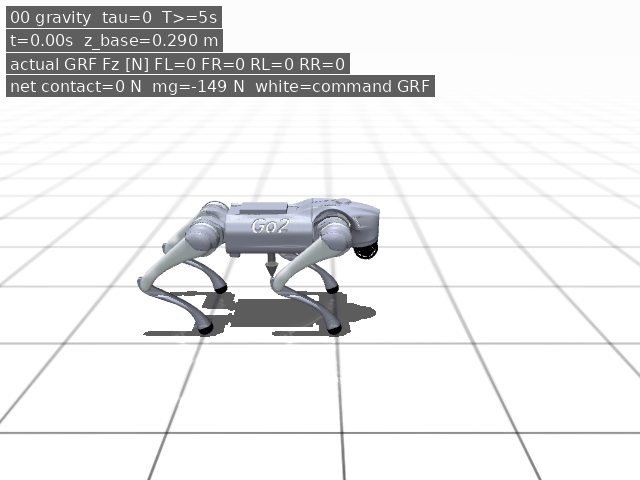

In [2]:
# --- このセルの意図 ---
# 数値合否のあと、同じ初期条件で GIF を残す。GIF が無い Notebook は結果が無い。

# 意図: 上のループで時間が進んでいるので、seed=0 で初期姿勢に戻して撮り直す
plant = MujocoGo2(scene="flat", seed=0)
gif = Path("assets/00_mujoco_go2_demo.gif")  # 内容: この Notebook の結果ファイル
path = render_rollout_gif(
    plant,
    gif,
    n_steps=n_steps,       # 内容: 上と同じ 5.5s。走行を短く切らない
    capture_every=60,      # 意図: 全ステップ録画すると重い。60 step = 0.12s に1枚
    title="00 gravity  tau=0  T>=5s",
)
# 内容: 色矢印=実接触 GRF、赤=合力、灰=mg。白（指令）はこの段には無い
print(path.resolve(), path.stat().st_size, "bytes", "t", float(plant.data.time))
display(Image(filename=str(path)))  # 意図: セル出力に GIF を出して Notebook だけで見られるようにする


## 分析

- 灰矢印（$mg$）は下向きで、質量が変わらなければ長さはほぼ一定
- 赤矢印は実接触の合力。空中ではほぼ 0、着地後に上向き成分が出る
- 足の矢印は指令ではない
- 合否は静止ではなく、**連続 5.0 s 以上 `qpos`/`qvel` が有限**であること（背景の表）

## 次の仮説

モータには上限がある。生の大きいトルクをそのまま `ctrl` に入れると、実機では出せない力をシミュレータが使う。次は飽和である。
